# 볼 모공 개수 학습 (5-fold 교차검증)

- 입력: 볼 좌/우 크롭 (기기 2개 × 각도 2개) → 출력: 그 볼의 모공 개수
- 설정은 `config.py`, 데이터는 `data.py`, 모델은 `model.py`에 있다. 실험은 `config.py`만 고치면 된다.
- **나누는 기준은 사람**이다. 같은 사람의 사진은 정답이 같아서, 섞이면 점수가 부풀려진다.
- 테스트용 165명(ailabtools 비교용)은 `data.load_rows()`가 알아서 빼준다.
- 평가는 두 가지로 본다.
  - **크롭 단위**: 사진 1장으로 얼마나 맞히나
  - **사람 단위**: 한 사람의 여러 사진 예측을 평균했을 때 (실제 서비스와 같은 조건)
- 정답은 `log(1+개수)`로 바꿔 학습하고, 평가할 때 원래 개수로 되돌린다.

In [9]:
import csv
import importlib
import json
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

import config
import data
import model as model_module

# .py 수정사항을 커널 재시작 없이 반영
importlib.reload(config)
importlib.reload(data)
importlib.reload(model_module)

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(config.SEED)
config.OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"장치 {config.DEVICE} | 백본 {config.BACKBONE}")
print(f"부위 {config.REGIONS} | 각도 {config.VIEWS} | 정답 {config.TARGET}")

장치 mps | 백본 convnext_tiny.fb_in22k_ft_in1k
부위 ['l_cheek', 'r_cheek'] | 각도 ['F', 'L', 'R'] | 정답 pore_count


## 데이터 확인

In [2]:
rows, test_rows = data.load_rows()
subjects = sorted({r["subject"] for r in rows})
counts = np.array([r["target"] for r in rows])

print(f"학습 대상 크롭 {len(rows):,}개, 사람 {len(subjects):,}명")
print(f"테스트 보관   크롭 {len(test_rows):,}개, 사람 {len({r['subject'] for r in test_rows}):,}명 (건드리지 않음)")
print(f"모공 개수: 중앙 {np.median(counts):.0f}, 범위 {counts.min():.0f}~{counts.max():.0f}")
print(f"입력 크기 (H, W): {data.input_size()}")

image, target, _ = data.CheekPoreDataset(rows, *data.target_stats(rows))[0]
print(f"샘플 텐서 {tuple(image.shape)}, 정답(정규화) {float(target):.3f}")

학습 대상 크롭 6,367개, 사람 800명
테스트 보관   크롭 1,316개, 사람 165명 (건드리지 않음)
모공 개수: 중앙 875, 범위 10~2438
입력 크기 (H, W): (576, 512)
샘플 텐서 (3, 576, 512), 정답(정규화) -0.318


## 학습·평가 함수

In [ ]:
def make_loader(rows, mean, std, train):
    dataset = data.CheekPoreDataset(rows, mean, std, train=train)
    return DataLoader(dataset, batch_size=config.BATCH_SIZE, shuffle=train, num_workers=config.NUM_WORKERS,
                      drop_last=train, persistent_workers=config.NUM_WORKERS > 0)


def predict(net, loader, mean, std):
    """예측을 원래 단위(모공 개수)로 되돌려 돌려준다."""
    net.eval()
    preds, targets, indices = [], [], []
    with torch.no_grad():
        for images, target, index in loader:
            preds.append(net(images.to(config.DEVICE)).cpu().numpy())
            targets.append(target.numpy())
            indices.append(index.numpy())
    preds, targets, indices = np.concatenate(preds), np.concatenate(targets), np.concatenate(indices)
    return np.expm1(preds * std + mean), np.expm1(targets * std + mean), indices


def score(preds, targets):
    return dict(mae=float(np.abs(preds - targets).mean()), spearman=float(spearmanr(preds, targets).statistic))


def by_subject(rows, preds, targets, indices):
    """같은 사람·같은 부위의 여러 사진 예측을 평균한다."""
    grouped = defaultdict(list)
    for pred, target, i in zip(preds, targets, indices):
        row = rows[i]
        grouped[(row["subject"], row["region"])].append((pred, target))
    pred_mean = np.array([np.mean([p for p, _ in v]) for v in grouped.values()])
    target_mean = np.array([v[0][1] for v in grouped.values()])
    return score(pred_mean, target_mean)


def run_fold(fold, train_rows, valid_rows, epochs):
    mean, std = data.target_stats(train_rows)  # 검증 fold 정보는 쓰지 않는다
    train_loader = make_loader(train_rows, mean, std, train=True)
    valid_loader = make_loader(valid_rows, mean, std, train=False)

    net = model_module.PoreModel().to(config.DEVICE)
    optimizer = torch.optim.AdamW(net.param_groups(), weight_decay=config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))
    loss_fn = nn.SmoothL1Loss()  # 이상치(모공 2000개 같은 경우)에 덜 휘둘린다

    best, bad_epochs, history = {"spearman": -1}, 0, []
    for epoch in range(1, epochs + 1):
        net.train()
        started, total_loss = time.time(), 0.0
        for images, target, _ in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(net(images.to(config.DEVICE)), target.to(config.DEVICE))
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        preds, targets, indices = predict(net, valid_loader, mean, std)
        crop_score = score(preds, targets)
        subject_score = by_subject(valid_rows, preds, targets, indices)
        history.append(dict(epoch=epoch, loss=total_loss / len(train_loader), **subject_score))
        print(f"  epoch {epoch:2d}  loss {total_loss / len(train_loader):.4f}  "
              f"크롭: MAE {crop_score['mae']:6.1f} 상관 {crop_score['spearman']:.3f}  |  "
              f"사람: MAE {subject_score['mae']:6.1f} 상관 {subject_score['spearman']:.3f}  "
              f"({time.time() - started:.0f}초)", flush=True)

        if subject_score["spearman"] > best["spearman"]:
            best = dict(subject_score, epoch=epoch, crop=crop_score,
                        preds=preds, targets=targets, indices=indices)
            torch.save({"model": net.state_dict(), "mean": mean, "std": std}, config.OUT_DIR / f"fold{fold}.pt")
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= config.PATIENCE:
                print(f"  {config.PATIENCE}번 좋아지지 않아 중단")
                break
    best["history"] = history
    return best

## 학습 실행

- `FOLDS`: 돌릴 fold 수 (전체는 `config.FOLDS` = 5)
- `LIMIT`: 크롭 수 제한. 코드가 도는지만 볼 때 `120` 정도로 두면 몇 분 안에 끝난다. 전체는 `None`

In [5]:
FOLDS = 1               # 먼저 1개만 (전체는 config.FOLDS = 5)
EPOCHS = 5              # 흐름 확인용. 잘 되면 늘린다
LIMIT = None            # 숫자를 넣으면 그만큼만 (동작 확인용)

use_rows = rows[:LIMIT] if LIMIT else rows
groups = [r["subject"] for r in use_rows]

results, oof = [], []
for fold, (train_idx, valid_idx) in enumerate(GroupKFold(n_splits=config.FOLDS).split(use_rows, groups=groups)):
    if fold >= FOLDS:
        break
    train_rows = [use_rows[i] for i in train_idx]
    valid_rows = [use_rows[i] for i in valid_idx]
    print(f"[fold {fold}] 학습 {len(train_rows):,} / 검증 {len(valid_rows):,} "
          f"(사람 {len({r['subject'] for r in train_rows})} / {len({r['subject'] for r in valid_rows})})")
    best = run_fold(fold, train_rows, valid_rows, EPOCHS)
    results.append(best)
    for pred, target, i in zip(best["preds"], best["targets"], best["indices"]):
        row = valid_rows[i]
        oof.append(dict(fold=fold, subject=row["subject"], device=row["device"], view=row["view"],
                        region=row["region"], pred=round(float(pred), 1), target=float(target)))

with open(config.OUT_DIR / "oof_predictions.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["fold", "subject", "device", "view", "region", "pred", "target"])
    writer.writeheader()
    writer.writerows(oof)
print("예측 저장:", config.OUT_DIR / "oof_predictions.csv")

[fold 0] 학습 5,093 / 검증 1,274 (사람 640 / 160)
  epoch  1  loss 0.1672  크롭: MAE  224.3 상관 0.792  |  사람: MAE  204.8 상관 0.831  (669초)
  epoch  2  loss 0.1112  크롭: MAE  202.0 상관 0.813  |  사람: MAE  186.9 상관 0.849  (410초)
  epoch  3  loss 0.0875  크롭: MAE  193.2 상관 0.825  |  사람: MAE  176.3 상관 0.858  (415초)
  epoch  4  loss 0.0692  크롭: MAE  191.4 상관 0.825  |  사람: MAE  171.4 상관 0.860  (414초)
  epoch  5  loss 0.0628  크롭: MAE  190.0 상관 0.827  |  사람: MAE  171.5 상관 0.861  (411초)
예측 저장: /Users/USER/Desktop/소마/face_analysis_AI/modeling/outputs/oof_predictions.csv


## 결과

fold 요약 (사람 단위)
  fold 0: MAE  171.5  상관 0.861  (epoch 5)
  평균   : MAE  171.5  상관 0.861


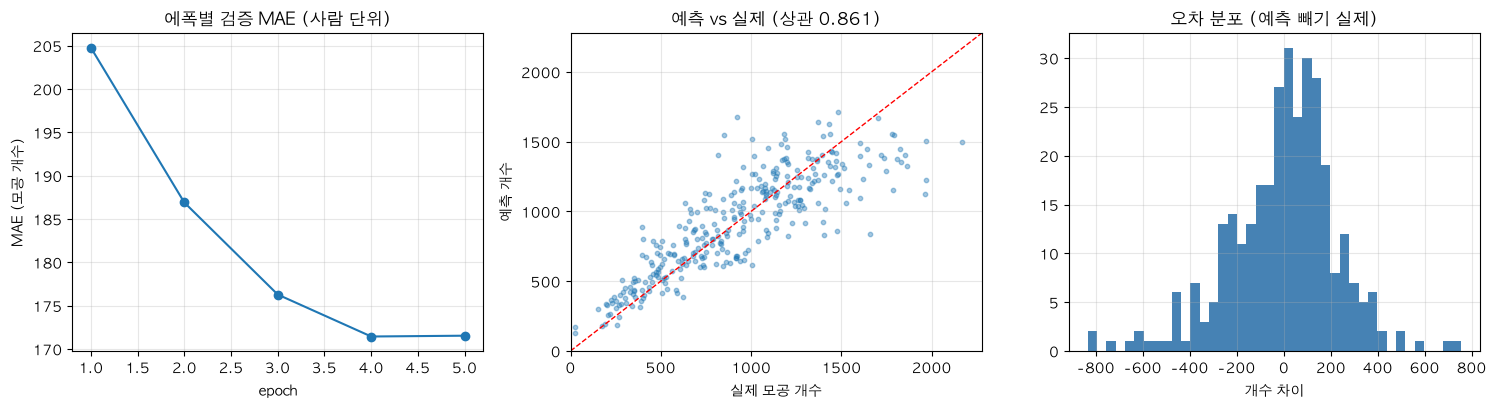

In [7]:
print("fold 요약 (사람 단위)")
for fold, best in enumerate(results):
    print(f"  fold {fold}: MAE {best['mae']:6.1f}  상관 {best['spearman']:.3f}  (epoch {best['epoch']})")
print(f"  평균   : MAE {np.mean([b['mae'] for b in results]):6.1f}  "
      f"상관 {np.mean([b['spearman'] for b in results]):.3f}")

# 사람 단위로 예측 평균내기
grouped = defaultdict(list)
for r in oof:
    grouped[(r["subject"], r["region"])].append((r["pred"], r["target"]))
pred_mean = np.array([np.mean([p for p, _ in v]) for v in grouped.values()])
true_mean = np.array([v[0][1] for v in grouped.values()])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for fold, best in enumerate(results):
    axes[0].plot([h["epoch"] for h in best["history"]], [h["mae"] for h in best["history"]], marker="o", label=f"fold {fold}")
axes[0].set_title("에폭별 검증 MAE (사람 단위)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MAE (모공 개수)"); axes[0].grid(alpha=.3)
if len(results) > 1:
    axes[0].legend()

axes[1].scatter(true_mean, pred_mean, s=10, alpha=.4)
lim = [0, max(true_mean.max(), pred_mean.max()) * 1.05]
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_title(f"예측 vs 실제 (상관 {spearmanr(pred_mean, true_mean).statistic:.3f})")
axes[1].set_xlabel("실제 모공 개수"); axes[1].set_ylabel("예측 개수"); axes[1].grid(alpha=.3)

axes[2].hist(pred_mean - true_mean, bins=40, color="steelblue")
axes[2].set_title("오차 분포 (예측 빼기 실제)"); axes[2].set_xlabel("개수 차이"); axes[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 테스트 평가 (165명) + ailabtools 비교

- 학습·검증에 한 번도 쓰지 않은 165명이다. `data.load_rows()`가 처음부터 빼둔 사람들이다.
- 같은 사람들을 상용 API(ailabtools)로도 돌려놨으므로, **같은 정답 기준으로 순위 상관을 비교**한다.
- 단위가 서로 달라서(우리는 기기 측정 개수, ailabtools는 자체 기준 개수·점수) 오차로는 비교할 수 없다.
- 저장된 `fold*.pt`를 모두 불러 평균낸다 (여러 fold를 돌렸으면 앙상블).


불러온 체크포인트: ['fold0.pt']

테스트 165명, 사람×부위 330개  (정답 중앙값 834개)

방법                            상관      MAE
-----------------------------------------
우리 모델                      0.867      164
ailabtools (모공 개수)         0.500    단위 다름

사람 단위 (좌우 볼 평균, 165명)
  우리 모델                    0.889      154
  ailabtools               0.519


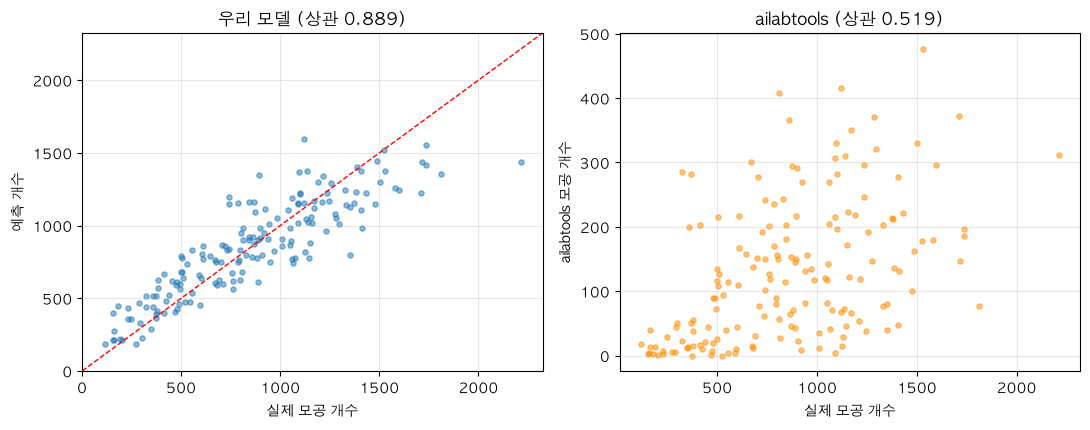

In [10]:
AILAB_DIR = config.ROOT / "ailabtools" / "test_set"

# --- 우리 모델 예측 (저장된 fold 체크포인트를 모두 평균) ---
checkpoints = sorted(config.OUT_DIR.glob("fold*.pt"))
print(f"불러온 체크포인트: {[p.name for p in checkpoints]}")

fold_preds = []
for path in checkpoints:
    saved = torch.load(path, map_location=config.DEVICE)
    if "model" in saved:
        state, mean, std = saved["model"], saved["mean"], saved["std"]
    else:  # mean/std를 함께 저장하기 전에 만든 예전 체크포인트
        state, (mean, std) = saved, data.target_stats(rows)
    net = model_module.PoreModel(pretrained=False).to(config.DEVICE)
    net.load_state_dict(state)
    loader = DataLoader(data.CheekPoreDataset(test_rows, mean, std), batch_size=config.BATCH_SIZE)
    preds, _, indices = predict(net, loader, mean, std)
    order = np.argsort(indices)
    fold_preds.append(preds[order])
pred_per_crop = np.mean(fold_preds, axis=0)

# 같은 (사람, 부위)의 여러 사진 예측을 평균
ours, truth = defaultdict(list), {}
for pred, row in zip(pred_per_crop, test_rows):
    ours[(row["subject"], row["region"])].append(pred)
    truth[(row["subject"], row["region"])] = row["target"]
ours = {k: float(np.mean(v)) for k, v in ours.items()}

# --- ailabtools 결과 ---
ailab = {}
for sid in {s["subject_id"] for s in json.loads((AILAB_DIR / "test_subjects_165.json").read_text())["subjects"]}:
    path = AILAB_DIR / "raw" / f"{sid}.json"
    if path.exists():
        r = json.loads(path.read_text())["result"]
        ailab[sid] = dict(l_cheek=r["enlarged_pore_count"]["left_cheek_count"],
                          r_cheek=r["enlarged_pore_count"]["right_cheek_count"],
                          score=r["score_info"]["pores_score"])

# --- 같은 사람·부위로 줄 세워 비교 ---
keys = sorted(k for k in ours if k[0] in ailab)
gt = np.array([truth[k] for k in keys])
our_pred = np.array([ours[k] for k in keys])
ail_count = np.array([ailab[k[0]][k[1]] for k in keys], dtype=float)

print(f"\n테스트 {len({k[0] for k in keys})}명, 사람×부위 {len(keys)}개  (정답 중앙값 {np.median(gt):.0f}개)")
def line(name, pred, target, show_mae=True):
    """스피어맨(순서를 맞히나) + 피어슨(값이 비례하나) + MAE"""
    mae = f"{np.abs(pred - target).mean():8.0f}" if show_mae else f"{'단위 다름':>8s}"
    print(f"{name:24s} {spearmanr(pred, target).statistic:8.3f} {pearsonr(pred, target).statistic:7.3f} {mae}")


print(f"\n{'방법':24s} {'스피어맨':>8s} {'피어슨':>7s} {'MAE':>8s}")
print("-" * 50)
line("우리 모델", our_pred, gt)
line("ailabtools (모공 개수)", ail_count, gt, show_mae=False)

# 사람 단위 (좌우 볼 평균)
subjects_test = sorted({k[0] for k in keys})
gt_s = np.array([np.mean([truth[(s, r)] for r in config.REGIONS if (s, r) in truth]) for s in subjects_test])
our_s = np.array([np.mean([ours[(s, r)] for r in config.REGIONS if (s, r) in ours]) for s in subjects_test])
ail_s = np.array([np.mean([ailab[s][r] for r in config.REGIONS]) for s in subjects_test])
print(f"\n사람 단위 (좌우 볼 평균, {len(subjects_test)}명)")
line("  우리 모델", our_s, gt_s)
line("  ailabtools", ail_s, gt_s, show_mae=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(gt_s, our_s, s=14, alpha=.5)
lim = [0, max(gt_s.max(), our_s.max()) * 1.05]
axes[0].plot(lim, lim, "r--", lw=1); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_title(f"우리 모델 (스피어맨 {spearmanr(our_s, gt_s).statistic:.3f}, 피어슨 {pearsonr(our_s, gt_s).statistic:.3f})")
axes[0].set_xlabel("실제 모공 개수"); axes[0].set_ylabel("예측 개수"); axes[0].grid(alpha=.3)

axes[1].scatter(gt_s, ail_s, s=14, alpha=.5, color="darkorange")
axes[1].set_title(f"ailabtools (스피어맨 {spearmanr(ail_s, gt_s).statistic:.3f}, 피어슨 {pearsonr(ail_s, gt_s).statistic:.3f})")
axes[1].set_xlabel("실제 모공 개수"); axes[1].set_ylabel("ailabtools 모공 개수"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()